<a href="https://colab.research.google.com/github/Chetna6may/Bank-Managment/blob/main/Copy_of_Customer_Segmentation_KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
!wget -O Mall_Customers.csv https://raw.githubusercontent.com/tanishq21/Mall-Customers/main/Mall_Customers.csv

--2026-10-05 19:59:17--  https://raw.githubusercontent.com/tanishq21/Mall-Customers/main/Mall_Customers.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4286 (4.2K) [text/plain]
Saving to: ‘Mall_Customers.csv’

Mall_Customers.csv  100%[===================>]   4.19K  --.-KB/s    in 0s      

2026-10-05 19:59:17 (49.8 MB/s) - ‘Mall_Customers.csv’ saved [4286/4286]



In [ ]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.shape

(200, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
X = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


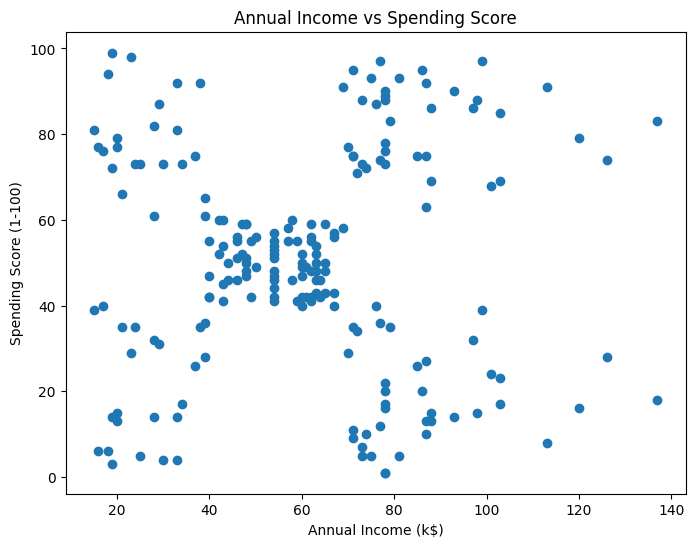

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Annual Income vs Spending Score")

plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

In [ ]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

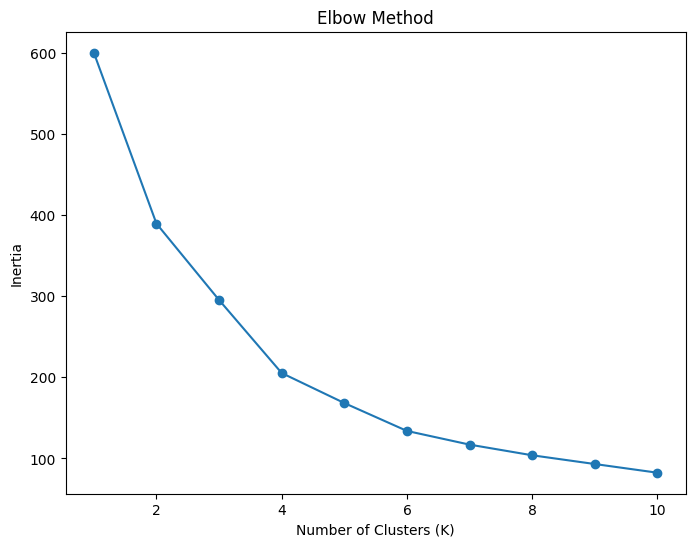

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(range(1, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

In [ ]:
kmeans.fit(X_scaled)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [ ]:
df["Cluster"] = kmeans.labels_

In [ ]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


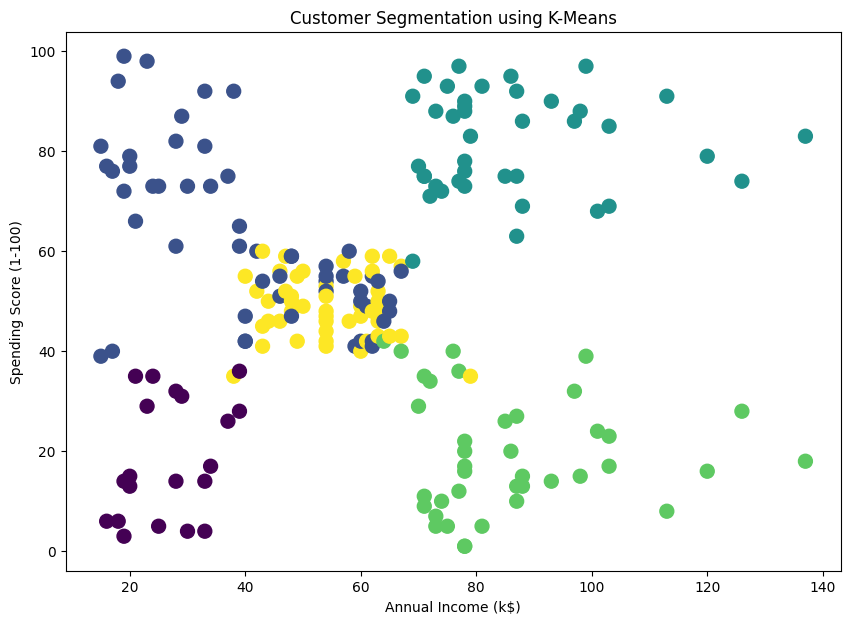

In [ ]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    s=100
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")

plt.show()

In [ ]:
cluster_summary = df.groupby("Cluster")[
    ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


In [ ]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers_df = pd.DataFrame(
    centers,
    columns=[
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
)

centers_df

,Age,Annual Income (k$),Spending Score (1-100)
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


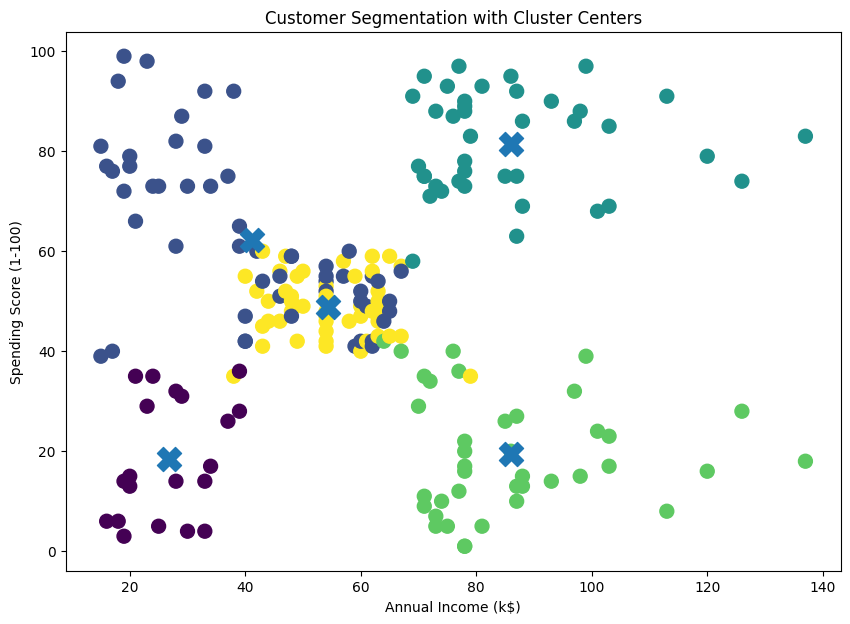

In [ ]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    s=100
)

plt.scatter(
    centers_df["Annual Income (k$)"],
    centers_df["Spending Score (1-100)"],
    marker="X",
    s=300
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation with Cluster Centers")

plt.show()

In [ ]:
new_customer = [[30, 70, 80]]

In [ ]:
new_customer_scaled = scaler.transform(new_customer)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
predicted_cluster = kmeans.predict(new_customer_scaled)

print("Predicted Cluster:", predicted_cluster[0])

Predicted Cluster: 2


In [ ]:
df.to_csv("customer_segments.csv", index=False)

In [ ]:
cluster_names = {
    0: "Low Income - Low Spending",
    1: "Young High-Spending Customers",
    2: "Premium High-Value Customers",
    3: "High Income - Low Spending",
    4: "Older Moderate Customers"
}

df["Customer Segment"] = df["Cluster"].map(cluster_names)

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster,Customer Segment
0,1,Male,19,15,39,1,Young High-Spending Customers
1,2,Male,21,15,81,1,Young High-Spending Customers
2,3,Female,20,16,6,0,Low Income - Low Spending
3,4,Female,23,16,77,1,Young High-Spending Customers
4,5,Female,31,17,40,1,Young High-Spending Customers


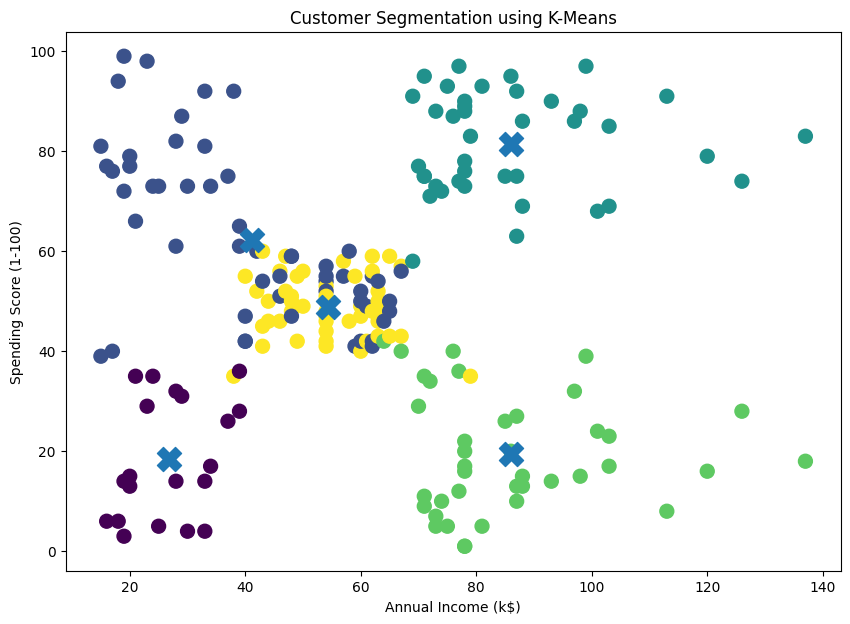

In [ ]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    s=100
)

plt.scatter(
    centers_df["Annual Income (k$)"],
    centers_df["Spending Score (1-100)"],
    marker="X",
    s=300
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")

plt.show()

## Conclusion

In this project, K-Means Clustering was used to segment customers based on Age, Annual Income, and Spending Score.

The Elbow Method was used to determine a suitable number of clusters, and K-Means was then applied to group similar customers.

The model identified five customer segments:

- Cluster 0: Low Income - Low Spending
- Cluster 1: Young High-Spending Customers
- Cluster 2: Premium High-Value Customers
- Cluster 3: High Income - Low Spending
- Cluster 4: Older Moderate Customers

Cluster 2 represents the high-value customer segment because it has both high annual income and high spending score. Cluster 3 is also an important segment because customers have high income but relatively low spending, making them potential targets for personalized marketing.

The project demonstrates how unsupervised machine learning can be used to discover meaningful customer groups and support data-driven marketing strategies.